In [18]:
# Necessary libraries and useful parameters
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scipy.sparse as sp
import warnings
warnings.simplefilter("ignore", RuntimeWarning)

newparams = {'font.family': 'cmr10', 'mathtext.fontset': 'cm',
             'axes.grid': False, 'axes.labelsize': 22,
             'xtick.labelsize': 18, 'ytick.labelsize': 18,
             'legend.fontsize': 18, 'axes.titlesize': 20,
             'axes.formatter.use_mathtext': True}
plt.rcParams.update(newparams)
%matplotlib inline

colors = ["#00274D", "#1B4F72", "#CFA6A6", "#CD5C5C", "#8B3A3A", "#641010"]
blue_red_cmap = mcolors.LinearSegmentedColormap.from_list("custom_blue_map", colors)

In [19]:
# A 2D contour map of C
def contour_plot(Z, R, C, cmap=blue_red_cmap, cbar_label=r'$c/c_{\mathrm{ref}}$', output_file=None):
    contour = plt.contourf(Z, R, C, levels=200, cmap=cmap, vmax=1)
    cbar = plt.colorbar(contour, label=cbar_label)
    
    plt.xlabel('$z/L$')
    plt.ylabel('$r/R$')
    plt.gca().set_aspect(aspect=0.6, adjustable='box')
    if output_file is not None:
        plt.savefig(output_file, bbox_inches='tight')
    plt.show()

In [20]:
# Model constants
R = 0.1   # tube radius [m]
L = 1     # tube length [m]
tau = 100 # Characteristic time

# Scaled constants
D = 2           # diffusion coefficient
A = 0.2         # electrical advection coefficient
B = -5          # velocity advection coefficient (B < 0)
kA, kB = 100, 2 # Langmuir constants

domain = ((0, 1), (0, 1), (0, 1))
M, K = 200, 200
h, ht = 1/M, 1/K

z = np.linspace(domain[0][0], domain[0][1], M+1)
r = np.linspace(domain[1][0], domain[1][1], M+1)
t = np.linspace(domain[2][0], domain[2][1], K+1)

grid = (z, r)
ZZ, RR = np.meshgrid(z, r) 

# Scaled block matrix coefficients
delta = ht/h**2 * D
gamma = delta * (R/L)**2
alpha = ht/h * A/r
beta = ht/h * B*(1-r**2)
omega = beta - alpha - 2*(gamma + delta) - 1

In [21]:
def coeff_matrix(M : int) -> sp.csr_matrix:
    '''
    Create the block tridiagonal matrix A to solve AC^k+1 + g = -C^k.
    Input:
        M: number of grid points
    '''
    Z = M*(M-1)

    ll = np.full(Z, delta)                 # Lowest diag
    l = np.repeat(gamma - beta[1:-1], M)   # Next lowest diag
    d = np.repeat(omega[1:-1], M)          # Main diag
    u = np.full(Z, gamma)                  # Next highest diag
    uu = np.repeat(delta + alpha[1:-1], M) # Highest diag
    
    l[M-1::M], u[M-1::M] = 0, 0  # Every M'th element is zero in l and d
    
    A = sp.diags([ll, l, d, u, uu], [-M, -1, 0, 1, M], (Z, Z), format='csr')

    return A

In [22]:
def boundary_vector(grid : tuple, k : int, Ck : np.ndarray, BC : tuple, M : int) -> np.ndarray:
  ''' 
  Create the boundary vector g to solve AC^k+1 + g = -C^k.
  Input:
    grid: (r, z) grids in r- and z directions
       k: the previous iteration step
      Ck: the previous concentration matrix
      BC: (g1, g2, g3) boundary condition functions
       M: number of grid points
  '''
  z, r = grid
  g1, g2 = BC
  
  # Construct a matrix containing boundary contributions.
  G = np.zeros((M-1, M))
  G[::-1, 0] += (gamma-beta[1:-1]) * g1(r[1:-1], t[k+1]) # Left contribution
  G[-1, :] += delta * g2(z[1:], t[k+1])                   # Bottom contribution
  G[0, :] += (delta+alpha[1:]) * (ht*(kA-kB*Ck[0, 1:]) + Ck[0, 1:]) # Top contribution

  return G[::-1].ravel() # return G as a vector

In [23]:
def concentration_scheme(grid : tuple, A : np.ndarray, k: int, Ck : np.ndarray, g : np.ndarray, BC : tuple, M : int) -> np.ndarray:
    '''
    Calculate the next concentration matrix C^k+1.
    Input:
        grid: (r, z) grids in r- and z directions
           A: the coefficient matrix
           k: the previous iteration step
          Ck: the previous concentration matrix
           g: the boundary vector
          BC: (g1, g2, g3) boundary condition functions
           M: number of grid points
    '''
    z, r = grid
    g1, g2 = BC
   
    C = np.zeros((M+1, M+1))
    C[::-1, 0] = g1(r, t[k+1])    # Left boundary
    C[-1, :] = g2(z, t[k+1])      # Bottom boundary
   
    C_interior = sp.linalg.spsolve(A, -(g + Ck[1:-1, 1:][::-1].ravel()))
    C[1:-1, 1:] = np.reshape(C_interior, (M-1, M))
   
    return C

In [24]:
# Initial condition
def f(z, r):                   
    return np.zeros_like(ZZ)   
                                                         
# Boundary conditions
def i(r, t): # inlet
    return 1-r**2  

def e(z, t): # electric
    return 0

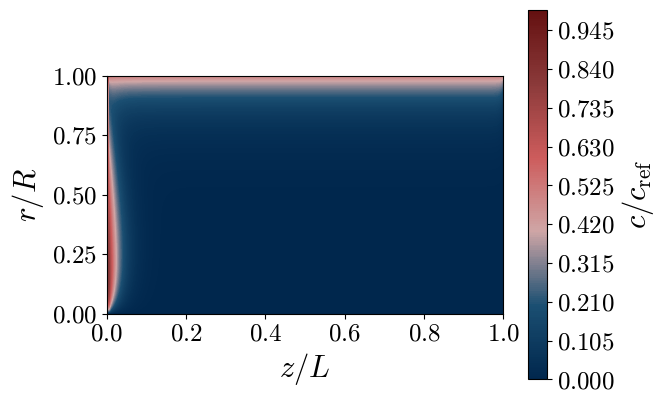

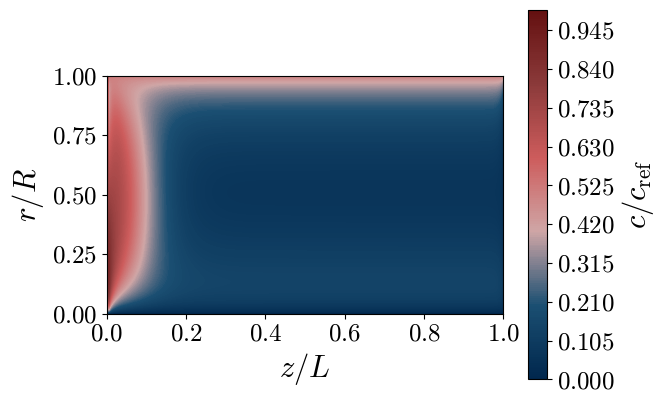

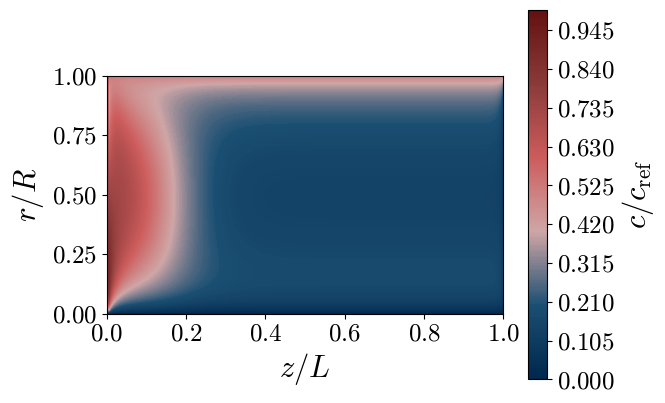

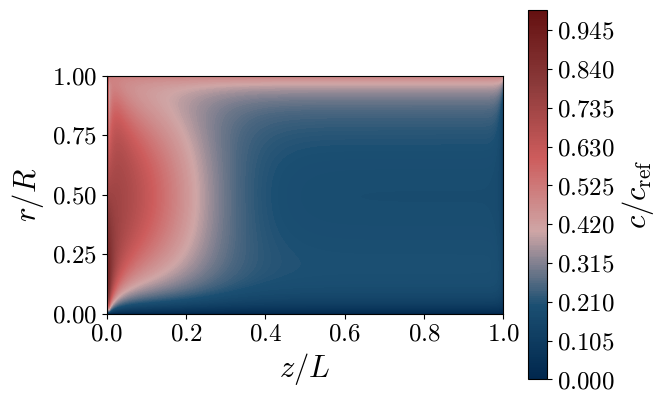

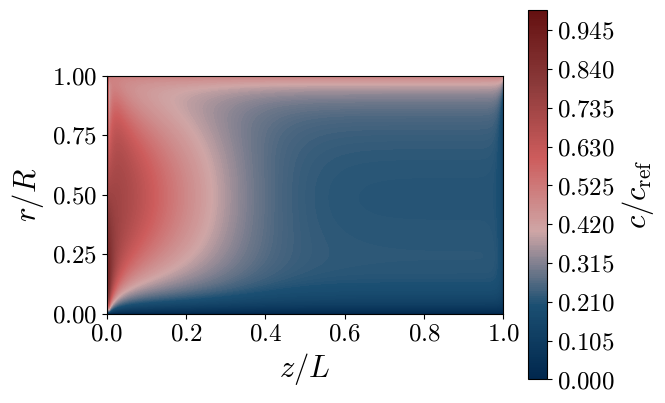

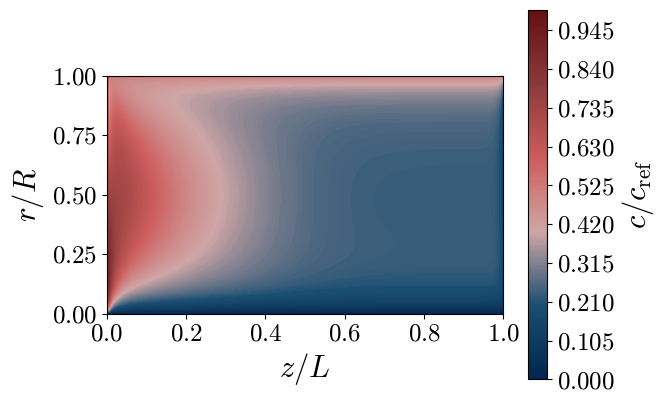

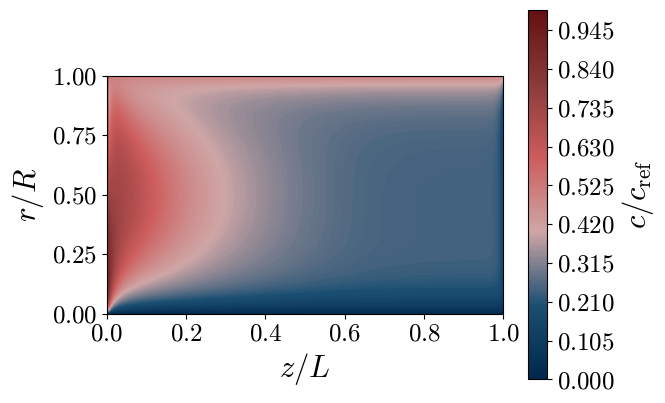

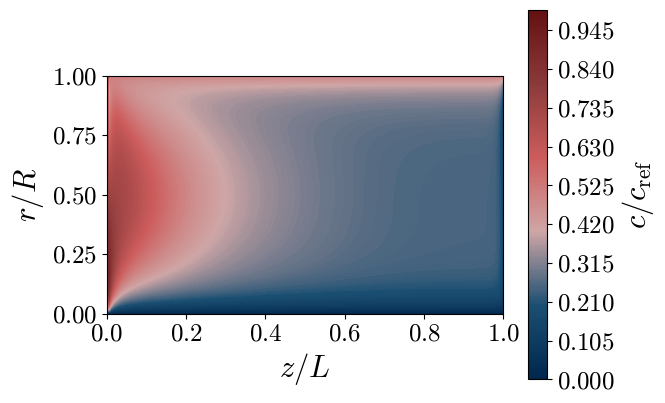

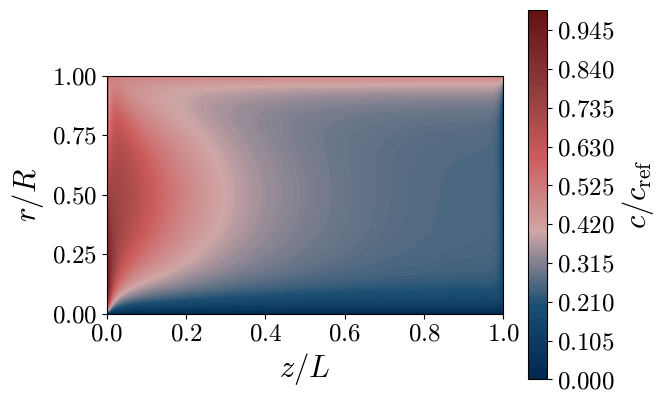

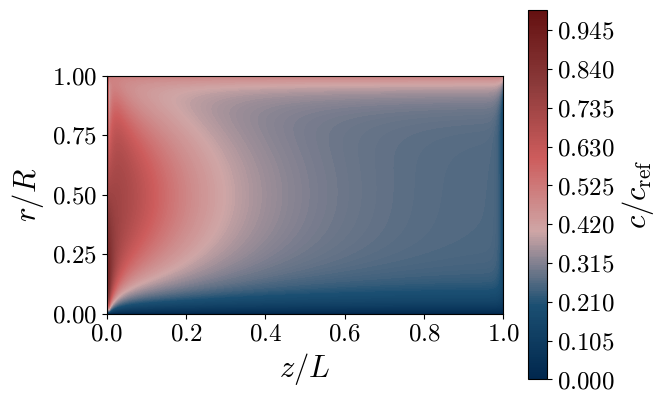

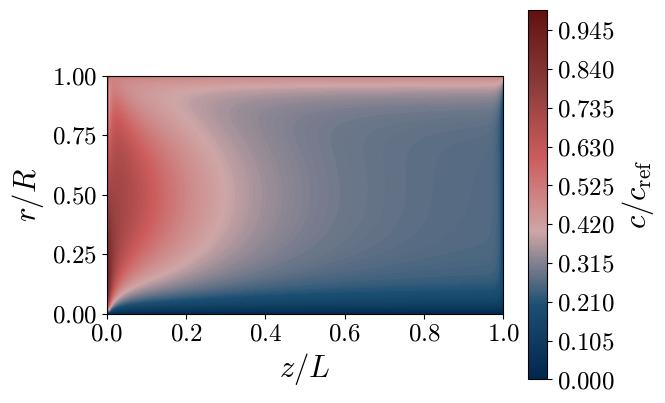

In [ ]:
# Example
BC = (i, e)
A_matr = coeff_matrix(M)
C0 = f(ZZ, RR) # Initial concentration matrix

Ck = C0
alphanumeric = 65
for k in range(tau):
    g = boundary_vector(grid, k, Ck, BC, M)
    C = concentration_scheme(grid, A_matr, k, Ck, g, BC, M)

    if k%5 == 0:
        plt.figure()
        contour_plot(ZZ, RR, C, output_file=f"output/{chr(alphanumeric)}.png")
        alphanumeric += 1
    Ck = C

In [ ]:
from PIL import Image
import glob

img = [] 
frames = [] 
fig = plt.figure()
files = glob.glob("./output/*.png")
files = sorted(files)

images = [Image.open(img).convert('RGB') for img in files]

images[0].save(
    'fds.gif',
    save_all=True,
    append_images=images[1:],
    duration=300,              
    loop=0           
)